# Thesis figures (provisional)

**Status**: all figures here are **provisional**. They earn their place in
the thesis body only if the supporting narrative in
`_identification_target.md` holds up. If any of the supporting findings is
later withdrawn or narrowed, the corresponding figure is deleted from this
notebook and from the thesis.

**Scope**: three figures total, one per narrative layer:
1. **System layer** — A87 monthly financial balance
2. **Structural layer** — Big-4 monthly Lerner index
3. **Behavioural layer** — XBID 2×2 liquidity panel

Each figure is saved as PDF + PNG in `figures/` with a caption sidecar
for LaTeX inclusion.


In [1]:
import warnings, json
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from mtu.notebook_utils import (
    PROJECT_ROOT,
    IDA_REFORM, ISP15_REFORM, INTRADAY_REFORM, DAY_AHEAD_REFORM,
    add_regime_shading,
)

warnings.filterwarnings('ignore')
mpl.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'pdf.fonttype': 42,     # embed TrueType — LaTeX-friendly
    'ps.fonttype': 42,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

COLORS = {'GE':'C3', 'IB':'C0', 'GN':'C1', 'HC':'C2'}

A87 = PROJECT_ROOT / 'data/processed/entsoe/balancing/financial_balance_all.parquet'
LER = PROJECT_ROOT / 'data/derived/firm_lerner_hourly.parquet'
XBID = PROJECT_ROOT / 'data/derived/xbid_liquidity_hourly.parquet'

con = duckdb.connect()
con.execute("SET memory_limit='6GB'"); con.execute("SET threads=4")

def save_fig(fig, name, caption):
    pdf_path = FIG_DIR / f'{name}.pdf'
    png_path = FIG_DIR / f'{name}.png'
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, bbox_inches='tight', dpi=150)
    (FIG_DIR / f'{name}.caption.json').write_text(
        json.dumps({'caption': caption, 'figure_id': name}, indent=2))
    print(f'  → saved {pdf_path.name} + .png + .caption.json')
    return fig


## Fig 1 — A87 monthly financial balance (system layer)

The strongest single data point for the reform's system-level signature.
Two series: A01 (TSO→BSPs) expenses and A02 (BRPs→TSO) net income.
The net-income line tells the story cleanly.


  → saved fig1_a87_financial_balance.pdf + .png + .caption.json


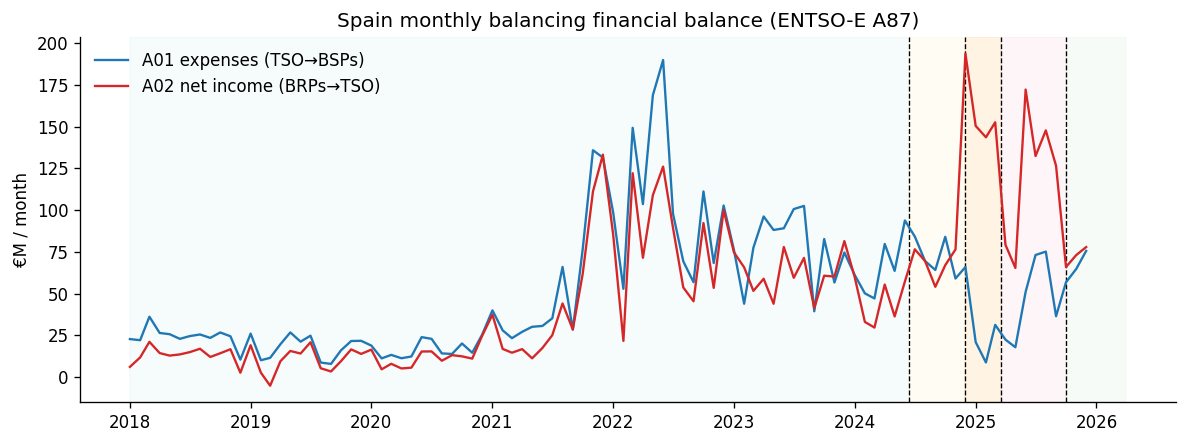

In [2]:
df = con.sql(f'''
    SELECT month,
           MAX(CASE WHEN direction_code='A01' THEN amount_eur END)/1e6 AS expenses_meur,
           MAX(CASE WHEN direction_code='A02' THEN amount_eur END)/1e6 AS net_income_meur
    FROM '{A87}'
    GROUP BY month ORDER BY month
''').df()
df['month'] = pd.to_datetime(df['month'])

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(df['month'], df['expenses_meur'],   color='C0', lw=1.4,
        label='A01 expenses (TSO→BSPs)')
ax.plot(df['month'], df['net_income_meur'], color='C3', lw=1.4,
        label='A02 net income (BRPs→TSO)')
add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
ax.set_ylabel('€M / month')
ax.set_title('Spain monthly balancing financial balance (ENTSO-E A87)')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
save_fig(fig, 'fig1_a87_financial_balance',
    'Monthly balancing financial balance for Spain, TR 17.1.i. '
    'Expenses (blue) represent TSO payments to balancing-service providers; '
    'net income (red) represents imbalance-settlement receipts from BRPs. '
    'Net income jumps from ~€38M/mo pre-reform to €160M/mo at ISP15 '
    '(1 Dec 2024), reflecting the elimination of intra-hour imbalance netting; '
    'it moderates to €72M/mo at MTU15-DA as 15-min trading tools spread '
    'across markets.')
plt.show()


## Fig 2 — Big-4 monthly Lerner index (structural layer)

Central thesis claim. Median $L_i = q_i / (p^*(1-s_i)|\partial S/\partial p|)$
per firm, monthly, trimmed to $[0,1]$ to remove supply-slope-outlier blow-ups.
GE peaks at 35% in DA60/ID15 and moderates to 10% at MTU15-DA.


  → saved fig2_big4_lerner_monthly.pdf + .png + .caption.json


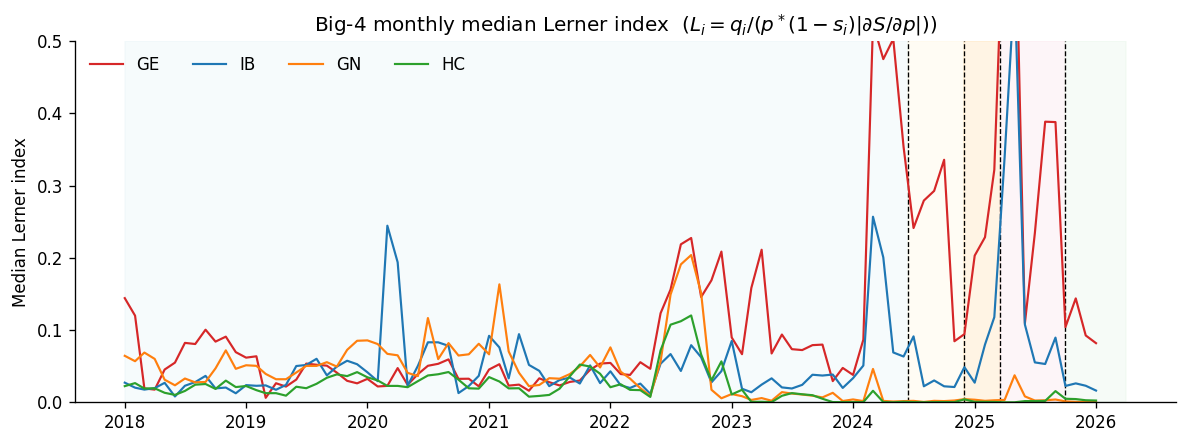

In [3]:
df = con.sql(f'''
    SELECT date, firm, lerner_index
    FROM '{LER}'
    WHERE lerner_index BETWEEN 0 AND 1
''').df()
df['date'] = pd.to_datetime(df['date'])
df['ym'] = df['date'].dt.to_period('M').dt.to_timestamp()
monthly = df.groupby(['ym','firm'])['lerner_index'].median().reset_index()

fig, ax = plt.subplots(figsize=(10, 3.8))
for f in ['GE','IB','GN','HC']:
    sub = monthly[monthly['firm']==f]
    ax.plot(sub['ym'], sub['lerner_index'], color=COLORS[f], lw=1.3, label=f)
add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
ax.set_ylabel('Median Lerner index')
ax.set_title(r'Big-4 monthly median Lerner index'
             r'  ($L_i = q_i / (p^* (1-s_i) |\partial S/\partial p|)$)')
ax.legend(loc='upper left', frameon=False, ncol=4)
ax.set_ylim(0, 0.5)
plt.tight_layout()
save_fig(fig, 'fig2_big4_lerner_monthly',
    'Monthly median Lerner index per Big-4 firm, estimated from the '
    'Cournot-Nash first-order condition using aggregate supply-curve slope '
    'at the day-ahead clearing price. Endesa (GE) rises from ~5% pre-reform '
    'to a peak of 35% in DA60/ID15 (Mar-Sep 2025), moderating to 10% at '
    'MTU15-DA. IB (Iberdrola), GN (Naturgy), HC (HC-Energía) remain at or '
    'below 5%. Series trimmed to [0,1] to exclude supply-slope-outlier hours.')
plt.show()


## Fig 3 — XBID 2×2 liquidity panel (behavioural layer)

Four-panel view of continuous-intraday liquidity: orders/hour, trades/hour,
fill rate, and trade-price dispersion. All four peak in the DA60/ID15
window and moderate at MTU15-DA.


  → saved fig3_xbid_liquidity.pdf + .png + .caption.json


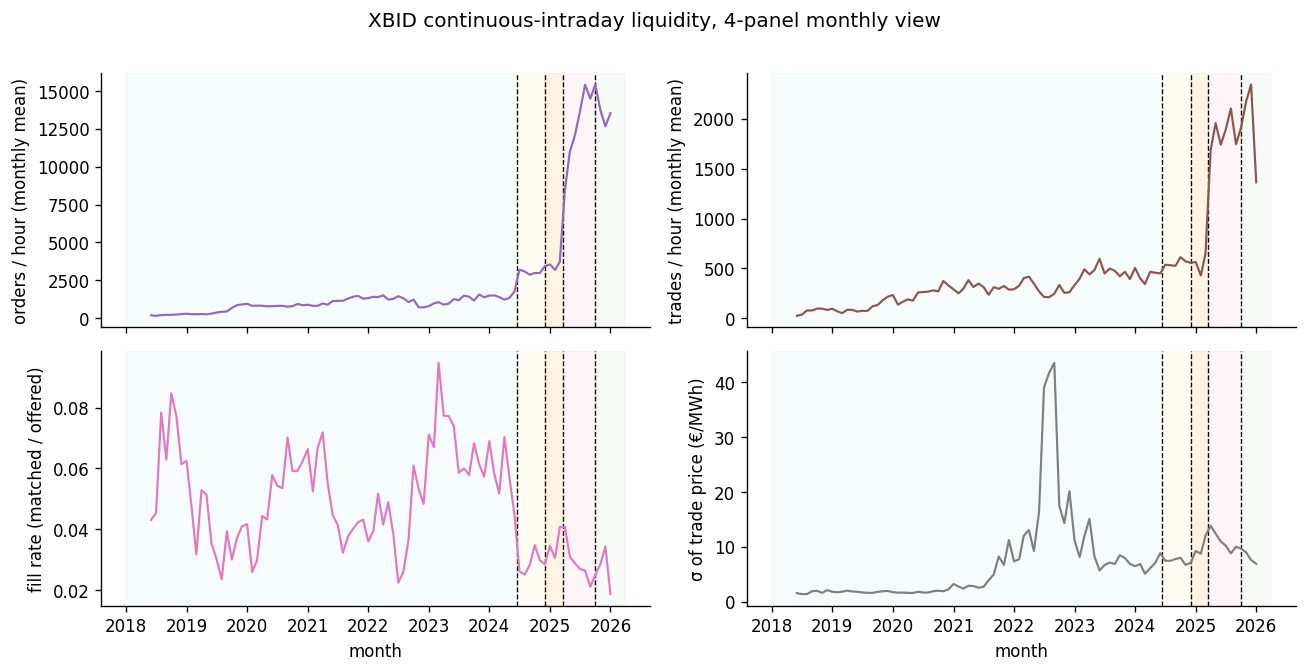

In [4]:
df = con.sql(f'''
    SELECT date, n_orders, n_trades, fill_rate, sd_trade_price
    FROM '{XBID}'
''').df()
df['date'] = pd.to_datetime(df['date'])
df['ym'] = df['date'].dt.to_period('M').dt.to_timestamp()
monthly = df.groupby('ym').agg(
    orders=('n_orders','mean'),
    trades=('n_trades','mean'),
    fill=('fill_rate','mean'),
    sd_p=('sd_trade_price','mean'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(11, 5.5), sharex=True)
panels = [
    (axes[0,0], 'orders',  'orders / hour (monthly mean)',      'C4'),
    (axes[0,1], 'trades',  'trades / hour (monthly mean)',       'C5'),
    (axes[1,0], 'fill',    'fill rate (matched / offered)',      'C6'),
    (axes[1,1], 'sd_p',    'σ of trade price (€/MWh)',           'C7'),
]
for ax, col, ylab, color in panels:
    ax.plot(monthly['ym'], monthly[col], color=color, lw=1.3)
    add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
    ax.set_ylabel(ylab)
axes[1,0].set_xlabel('month')
axes[1,1].set_xlabel('month')
fig.suptitle('XBID continuous-intraday liquidity, 4-panel monthly view', y=1.01)
plt.tight_layout()
save_fig(fig, 'fig3_xbid_liquidity',
    'XBID continuous-intraday liquidity, monthly means. Orders per hour '
    'grow 15× from pre-IDA (~920) to DA15/ID15 (~13,900); fill rate falls '
    'from 5.2% to 2.7% as granularity finer; trade-price dispersion peaks '
    'at DA60/ID15 (€11.3/MWh) and normalises at MTU15-DA — concordant with '
    'the structural-markup pattern in Fig 2.')
plt.show()


---

## Status tracker

| Figure | Supporting narrative | Status |
|---|---|---|
| 1. A87 financial balance | nb11 §1, D14 four-way concordance at ISP15 | **provisional** |
| 2. Big-4 Lerner | nb12 Cournot-FOC structural markup; D15/D16 three-layer | **provisional** |
| 3. XBID liquidity | nb13 §2 behavioural-layer corroboration | **provisional** |

Delete a figure from this notebook **and** from `figures/` if its
supporting narrative is withdrawn.
